# MC-simulering v4: Stockpicking-skicklighet × Viktning × Portföljstorlek

Identisk metodik som `MC_Simulering_v3` men datan kommer uteslutande från `MCReturns.xlsx` (månadsdata 1982–2026).

Tre diskreta dimensioner varieras:
- **Bias**: `0.0 → 1.0` — graden av skicklighet i stockpicking (0 = slumpmässigt, 1 = alltid bästa halvan)
- **Viktning**: `equal`, `cap` (faktiska market caps från Sheet1), `risk_parity` (inverterad volatilitet)
- **Portföljstorlek**: 5, 10, 20, 100 aktier

Vid varje rebalanseringspunkt delas universumet i topp- och bottenhälft baserat på **framtida** avkastning (fusk framåt). Portföljerna rebalanseras årsvis (januari) med max 30 % omsättning per period. Benchmark = marknadsindexet i Sheet2.

In [95]:
import os
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
try:
    plt.style.use('kvartil.mplstyle')
except Exception:
    pass

## 1. Ladda data från MCReturns.xlsx

In [96]:
DATAFOLDER = r'C:\Users\JonasAnderssonTuomaa\OneDrive - Quartile Fonder AB\Documents\EXJobb 26\examensarbete-vt26\analysdata'
FILE_NAME = os.path.join(DATAFOLDER, 'MCReturns.xlsx')

MC_SHEET = 'Sheet1'
RETURNS_SHEET = 'Returns'
MARKET_RETURNS_SHEET = 'Sheet2'

START_DATE = '1982-01-01'
END_DATE = '2026-01-01'
MARKET_START_DATE = '1996-01-01'
MARKET_END_DATE = '2025-12-01'

# Switch: vilken serie ska användas som benchmark i resten av notebooken?
#   'sheet2'       -> marknadsindexet från Sheet2 (extern serie)
#   'cap_weighted' -> cap-viktad portfölj över hela universumet (Sheet1-vikter x Returns)
BENCHMARK_SOURCE = 'cap_weighted'


def load_data(file_name, mc_sheet, returns_sheet, start_date, end_date):
    mc = pd.read_excel(file_name, sheet_name=mc_sheet, na_values=['NA', '#VALUE!'])
    rets = pd.read_excel(file_name, sheet_name=returns_sheet, na_values=['NA', '#VALUE!'])

    dates = pd.date_range(start=start_date, end=end_date, freq='MS')
    mc.columns = mc.columns.map(lambda x: str(x).strip())
    rets.columns = rets.columns.map(lambda x: str(x).strip())
    mc.index = dates
    rets.index = dates
    mc = mc.apply(pd.to_numeric, errors='coerce')
    rets = rets.apply(pd.to_numeric, errors='coerce')

    common_cols = mc.columns.intersection(rets.columns)
    return mc[common_cols].copy(), rets[common_cols].copy()


def load_market_returns(file_name, market_sheet, start_date, end_date):
    market = pd.read_excel(
        file_name,
        sheet_name=market_sheet,
        header=None,
        usecols=[0],
        na_values=['NA', '#VALUE!'],
    )
    dates = pd.date_range(start=start_date, end=end_date, freq='MS')
    market.columns = ['market_return']
    market.index = dates
    market['market_return'] = pd.to_numeric(market['market_return'], errors='coerce')
    # Sheet2 är start-stämplad medan Returns är slut-stämplad — shifta ett steg
    # framåt så benchmarken stämmer datummässigt med Returns-arket.
    # (Verifierat empiriskt: corr(cw, bm.shift(1)) ≈ 0.97 vs ~0 utan shift.)
    market = market.shift(1).dropna()
    return market


def build_cap_weighted_index(mc_df, rets_df):
    '''Cap-viktad månadsavkastning över hela universumet. Vikter = föregående månads
    market cap (lag 1) för att undvika look-ahead. Returnerar DataFrame med kolumnen
    market_return så att samma kod nedströms fungerar oavsett källa.'''
    caps_lagged = mc_df.shift(1).where(rets_df.notna()).clip(lower=0)
    total_caps  = caps_lagged.sum(axis=1, min_count=1)
    weights     = caps_lagged.div(total_caps.where(total_caps > 0), axis=0)
    series      = (weights * rets_df).sum(axis=1, min_count=1)
    return series.to_frame('market_return').dropna()


MC_DF, AVKASTNINGAR = load_data(FILE_NAME, MC_SHEET, RETURNS_SHEET, START_DATE, END_DATE)

UNIVERSE = MC_DF.columns.intersection(AVKASTNINGAR.columns)
AVKASTNINGAR = AVKASTNINGAR[UNIVERSE]
MC_DF = MC_DF[UNIVERSE]

MARKET_RETURNS_SHEET2      = load_market_returns(FILE_NAME, MARKET_RETURNS_SHEET, MARKET_START_DATE, MARKET_END_DATE)
MARKET_RETURNS_CAPWEIGHTED = build_cap_weighted_index(MC_DF, AVKASTNINGAR)

if BENCHMARK_SOURCE == 'sheet2':
    MARKET_RETURNS = MARKET_RETURNS_SHEET2
elif BENCHMARK_SOURCE == 'cap_weighted':
    MARKET_RETURNS = MARKET_RETURNS_CAPWEIGHTED
else:
    raise ValueError(f"Okänt BENCHMARK_SOURCE: {BENCHMARK_SOURCE!r} (välj 'sheet2' eller 'cap_weighted')")

print(f'Universum     : {len(UNIVERSE)} bolag')
print(f'Period        : {AVKASTNINGAR.index[0].date()} -> {AVKASTNINGAR.index[-1].date()}')
print(f'Månader       : {len(AVKASTNINGAR)}')
print(f"Benchmark     : {BENCHMARK_SOURCE!r}  ({MARKET_RETURNS.index[0].date()} -> {MARKET_RETURNS.index[-1].date()},  {len(MARKET_RETURNS)} obs)")


Universum     : 3617 bolag
Period        : 1982-01-01 -> 2026-01-01
Månader       : 529
Benchmark     : 'cap_weighted'  (1982-03-01 -> 2026-01-01,  527 obs)


## 1b. Kontroll: cap-viktat universum vs benchmark

Sanity check innan vi går vidare till simuleringen — håller benchmarkindexet i `Sheet2` sig mot universumet i `Sheet1`/`Returns`?

Vi konstruerar en passiv cap-viktad portfölj över **alla** bolag (vikter = föregående månads market cap, applicerat på innevarande månads avkastning) och jämför kumulativ avkastning, volatilitet och tracking error mot marknadsindexet. Stor avvikelse signalerar att benchmark inte är representativ för det investerbara universumet — vilket i sin tur påverkar tolkningen av alla över-/underprestationsresultat senare i analysen.

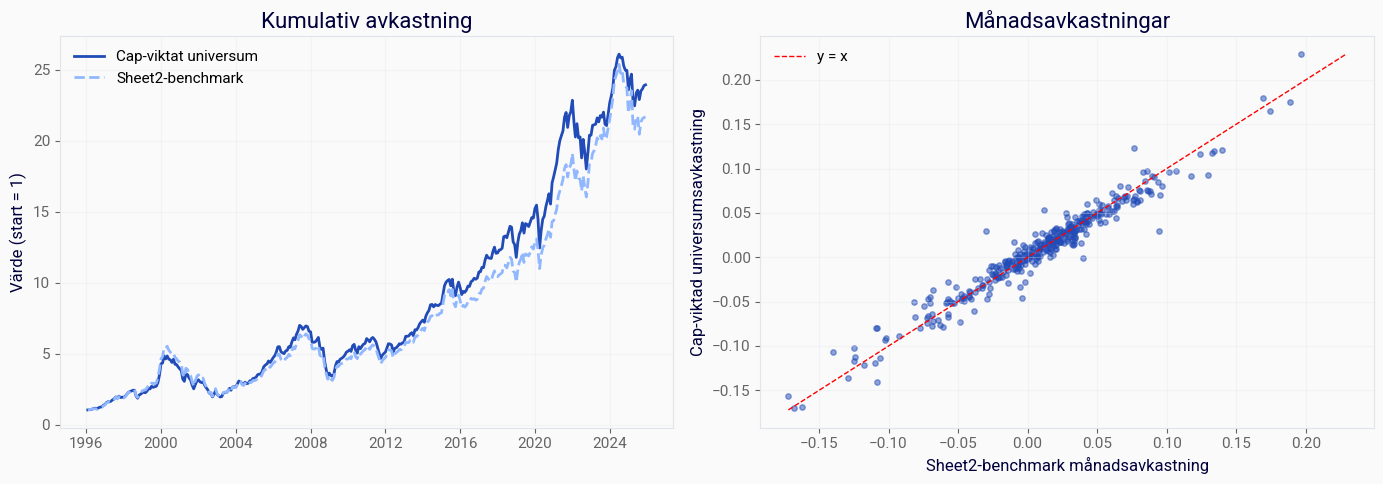

Period            : 1996-02-01 -> 2025-12-01  (359 månader)
Ann. avkastning   : cap-viktat =  11.23%   sheet2 =  10.86%   diff =  +0.37%
Ann. volatilitet  : cap-viktat =  18.04%   sheet2 =  18.81%
Korrelation       : 0.9737
Tracking error    : 4.29%
Aktiv benchmark (BENCHMARK_SOURCE) : 'cap_weighted'


In [97]:
# Jämför de två benchmark-kandidaterna (oberoende av BENCHMARK_SOURCE-switchen)
cw_full = MARKET_RETURNS_CAPWEIGHTED['market_return']
bm_full = MARKET_RETURNS_SHEET2['market_return']

common_idx = cw_full.index.intersection(bm_full.index)
cw = cw_full.loc[common_idx]
bm = bm_full.loc[common_idx]
mask = cw.notna() & bm.notna()
cw, bm = cw[mask], bm[mask]

cum_cw = (1 + cw).cumprod()
cum_bm = (1 + bm).cumprod()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cum_cw.index, cum_cw.values, label='Cap-viktat universum', linewidth=2)
axes[0].plot(cum_bm.index, cum_bm.values, label='Sheet2-benchmark', linewidth=2, linestyle='--')
axes[0].set_title('Kumulativ avkastning')
axes[0].set_ylabel('Värde (start = 1)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].scatter(bm.values, cw.values, alpha=0.5, s=15)
lim = [min(bm.min(), cw.min()), max(bm.max(), cw.max())]
axes[1].plot(lim, lim, 'r--', linewidth=1, label='y = x')
axes[1].set_xlabel('Sheet2-benchmark månadsavkastning')
axes[1].set_ylabel('Cap-viktad universumsavkastning')
axes[1].set_title('Månadsavkastningar')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

years   = (cw.index[-1] - cw.index[0]).days / 365.25
ann_cw  = cum_cw.iloc[-1] ** (1 / years) - 1
ann_bm  = cum_bm.iloc[-1] ** (1 / years) - 1
vol_cw  = cw.std() * np.sqrt(12)
vol_bm  = bm.std() * np.sqrt(12)
te      = (cw - bm).std() * np.sqrt(12)
corr    = cw.corr(bm)

print(f'Period            : {cw.index[0].date()} -> {cw.index[-1].date()}  ({len(cw)} månader)')
print(f'Ann. avkastning   : cap-viktat = {ann_cw:>7.2%}   sheet2 = {ann_bm:>7.2%}   diff = {ann_cw - ann_bm:>+7.2%}')
print(f'Ann. volatilitet  : cap-viktat = {vol_cw:>7.2%}   sheet2 = {vol_bm:>7.2%}')
print(f'Korrelation       : {corr:.4f}')
print(f'Tracking error    : {te:.2%}')
print(f"Aktiv benchmark (BENCHMARK_SOURCE) : {BENCHMARK_SOURCE!r}")


## 2. Hjälpfunktioner

In [98]:
def get_kfs(rets, benchrets, periods_yr=12, monthly_vol=False):
    rets_m = rets
    benchrets_m = (
        (1 + benchrets)
        .cumprod()
        .resample('ME')
        .last()
        .pct_change(fill_method=None)
        .dropna()
        .reindex(rets_m.index)
    )
    if len(rets) > len(rets_m) * 12:
        yrs = (rets.index[-1] - rets.index[0]) / np.timedelta64(365, 'D')
    else:
        yrs = len(rets_m) / 12
    dd = 1 - (1 + rets).cumprod() / (1 + rets).cumprod().expanding().max()
    yr = np.power((1 + rets).cumprod().iloc[-1], 1 / yrs) - 1
    if monthly_vol:
        yv = rets_m.std() * np.sqrt(12)
    else:
        yv = rets.std() * np.sqrt(periods_yr)
    max_dd          = dd.max()
    mean_dd         = dd.mean()
    ir              = yr / yv
    beta            = rets_m.corrwith(benchrets_m) * rets_m.std() / benchrets_m.std()
    downside_capture = rets_m[benchrets_m < 0].mean() / benchrets_m[benchrets_m < 0].mean()
    upside_capture   = rets_m[benchrets_m > 0].mean() / benchrets_m[benchrets_m > 0].mean()
    share_up_month  = (rets_m > 0).mean()
    avg_down_month  = rets_m[rets_m < 0].mean()
    avg_up_month    = rets_m[rets_m > 0].mean()
    rets_0          = rets.sub(rets.mean())
    upside_vol      = rets_0[rets_0 > 0].std() * np.sqrt(periods_yr)
    downside_vol    = rets_0[rets_0 < 0].std() * np.sqrt(periods_yr)
    batting_average = (rets_m.sub(benchrets_m, axis=0) >= 0.000001).mean()
    var95           = rets_m.quantile(0.05)
    var99           = rets_m.quantile(0.01)
    cvar            = rets_m[rets_m < var95].mean()
    skew            = rets_m.skew()
    kurtosis        = rets_m.kurtosis()
    sortino_ratio   = yr / downside_vol
    calmar_ratio    = yr / abs(max_dd)

    payload = {
        'Return': yr, 'Vol': yv, 'Max DrawDown': max_dd,
        'Information Ratio': ir, 'Beta': beta,
        'Downside Capture': downside_capture, 'Upside capture': upside_capture,
        'Share up month': share_up_month, 'Avg. down-month': avg_down_month,
        'Avg. up-month': avg_up_month, 'Downside vol.': downside_vol,
        'Upside vol.': upside_vol, 'Batting average': batting_average,
        'VaR 95%': var95, 'VaR 99%': var99, 'Conditional VaR (5%)': cvar,
        'Skew': skew, 'Kurtosis': kurtosis,
        'Sortinokvot': sortino_ratio, 'Calmarkvot': calmar_ratio,
    }

    if isinstance(yr, pd.Series):
        return pd.concat(payload, axis=1)
    return pd.Series(payload)

In [99]:
LOOKBACK_MONTHS = 36   # för aktivitetsfilter och risk_parity-volatilitet
MIN_OBS_MONTHS = 24


def get_forward_partition(date, next_date):
    '''
    Delar upp universumet i topp- och bottenhälft baserat på framtida avkastning
    (fuskar framåt — next_date är nästa rebalanseringstillfälle).
    '''
    fwd = AVKASTNINGAR.loc[date:next_date].add(1).prod(min_count=1) - 1
    fwd = fwd.dropna()

    window = AVKASTNINGAR.loc[:date].iloc[-LOOKBACK_MONTHS:]
    active = window.columns[window.count() >= MIN_OBS_MONTHS]
    fwd = fwd.reindex(active).dropna()

    median_ret = fwd.median()
    top_half = fwd[fwd >= median_ret].index.tolist()
    bot_half = fwd[fwd < median_ret].index.tolist()
    return top_half, bot_half


def get_bias_probs(top_half, bot_half, bias):
    '''bias=0 → likformig (slump), bias=1 → endast topphälvan.'''
    n_top = len(top_half)
    n_bot = len(bot_half)
    top_set = set(top_half)

    w_top = (0.5 + bias * 0.5) / n_top if n_top > 0 else 0.0
    w_bot = (0.5 - bias * 0.5) / n_bot if n_bot > 0 else 0.0

    all_stocks = top_half + bot_half
    weights = pd.Series(
        [w_top if s in top_set else w_bot for s in all_stocks],
        index=all_stocks,
        dtype=float,
    )
    total = weights.sum()
    if total > 0:
        return weights / total
    return pd.Series(1.0 / len(all_stocks), index=all_stocks)


def get_weights_v2(tickers, date, weighting):
    '''Portföljvikter: equal | cap (market caps från MC_DF) | risk_parity (inverterad volatilitet).'''
    tickers = list(tickers)
    n = len(tickers)

    if weighting == 'equal':
        return pd.Series(1.0 / n, index=tickers)

    elif weighting == 'cap':
        idx = MC_DF.index.get_indexer([date], method='nearest')[0]
        w = MC_DF.iloc[idx][tickers].fillna(0).clip(lower=0)
        s = w.sum()
        return w / s if s > 0 else pd.Series(1.0 / n, index=tickers)

    elif weighting == 'risk_parity':
        window = AVKASTNINGAR.loc[:date].iloc[-LOOKBACK_MONTHS:]
        vols = window[tickers].std()
        inv_vol = (1.0 / vols).replace([np.inf, -np.inf], np.nan).fillna(0)
        s = inv_vol.sum()
        return inv_vol / s if s > 0 else pd.Series(1.0 / n, index=tickers)

    else:
        raise ValueError(f'Okänd viktning: {weighting}')

In [102]:
def draw_initial_holdings(top_half, bot_half, pf_size, bias, rng):
    '''Drar startportfölj givet framtida partition och bias.'''
    all_stocks = top_half + bot_half
    if len(all_stocks) < pf_size:
        raise ValueError(
            f'För få aktiva aktier ({len(all_stocks)}) för pf_size={pf_size}'
        )
    probs = get_bias_probs(top_half, bot_half, bias)
    chosen = rng.choice(probs.index, size=pf_size, replace=False, p=probs.values)
    return list(chosen)


def rebalance_holdings(date, prev_holdings, top_half, bot_half, pf_size, bias, rng,
                       max_turnover=0.3):
    '''Uppdaterar innehav med begränsad omsättning. Stokastiskt urval viktat på bias-sannolikheter.'''
    all_stocks = set(top_half + bot_half)
    if len(all_stocks) < pf_size:
        return prev_holdings

    probs = get_bias_probs(top_half, bot_half, bias)
    still_active = [t for t in prev_holdings if t in all_stocks]

    n_forced = pf_size - len(still_active)
    n_swap   = max(int(np.floor(pf_size * max_turnover)), n_forced)
    n_keep   = pf_size - n_swap

    if still_active and n_keep > 0:
        active_probs = probs.reindex(still_active, fill_value=0)
        s = active_probs.sum()
        if s > 0:
            active_probs = active_probs / s
        else:
            active_probs = pd.Series(1.0 / len(still_active), index=still_active)
        keep_n = min(n_keep, len(still_active))
        keep = list(rng.choice(still_active, size=keep_n, replace=False, p=active_probs.values))
    else:
        keep = []

    candidates = probs.index.difference(keep)
    cand_probs = probs.reindex(candidates, fill_value=0)
    s = cand_probs.sum()
    cand_probs = cand_probs / s if s > 0 else pd.Series(1.0 / len(candidates), index=candidates)

    n_new = min(pf_size - len(keep), len(candidates))
    new_picks = rng.choice(candidates, size=n_new, replace=False, p=cand_probs.values)
    return keep + list(new_picks)


def evolve_positions_one_period(positions, t0, t1):
    '''
    Evolverar positions månad för månad mellan t0 (exklusivt) och t1 (inklusivt).
    Hanterar konkurs (r = −1) och avnotering (NaN) explicit som montecharlie:
      - r == −1   → position nollställs, ticker permanent inaktiv (konkurs)
      - r är NaN  → position fryses, ticker permanent inaktiv (avnotering)
    Returnerar (final_positions, monthly_portfolio_returns).
    '''
    positions = positions.copy().astype(float)
    tickers = positions.index.tolist()
    active = {t: True for t in tickers}

    period_rets = AVKASTNINGAR.loc[
        (AVKASTNINGAR.index > t0) & (AVKASTNINGAR.index <= t1),
        tickers,
    ]

    monthly_rets = []

    for dt, row in period_rets.iterrows():
        beginning_wealth = positions.sum()

        for ticker in tickers:
            if not active[ticker]:
                continue
            r = row[ticker]
            if pd.isna(r):
                if positions[ticker] > 0:
                    active[ticker] = False
                continue
            positions[ticker] = positions[ticker] * (1.0 + r)
            if r == -1:
                positions[ticker] = 0.0
                active[ticker] = False

        ending_wealth = positions.sum()
        if beginning_wealth > 0:
            pf_ret = ending_wealth / beginning_wealth - 1.0
        else:
            pf_ret = np.nan
        monthly_rets.append((dt, pf_ret))

    return positions, pd.Series(dict(monthly_rets))


def simulate_one_portfolio(bias, weighting, pf_size, seed, rebal_dates,
                           max_turnover=0.3, initial_wealth=1.0):
    '''Simulerar en portfölj med årlig ombalansering och montecharlie-stils
    konkurs/avnoteringshantering. Returnerar månadsavkastningar.'''
    rng = np.random.default_rng(seed)

    top_half, bot_half = get_forward_partition(rebal_dates[0], rebal_dates[1])
    holdings = draw_initial_holdings(top_half, bot_half, pf_size, bias, rng)
    weights  = get_weights_v2(holdings, rebal_dates[0], weighting)
    positions = (weights * initial_wealth).reindex(holdings, fill_value=0.0)

    all_returns = []

    for i in range(len(rebal_dates) - 1):
        t0 = rebal_dates[i]
        t1 = rebal_dates[i + 1]

        positions, monthly_rets = evolve_positions_one_period(positions, t0, t1)
        all_returns.append(monthly_rets)

        if i < len(rebal_dates) - 2:
            next_t = rebal_dates[i + 2]
            top_half, bot_half = get_forward_partition(t1, next_t)

            total_wealth = float(positions.sum())
            if total_wealth <= 0:
                continue

            new_holdings = rebalance_holdings(
                t1, list(positions.index), top_half, bot_half, pf_size, bias, rng,
                max_turnover,
            )
            new_weights = get_weights_v2(new_holdings, t1, weighting)
            positions = (new_weights * total_wealth).reindex(new_holdings, fill_value=0.0)

    combined = pd.concat(all_returns).sort_index()
    return combined.groupby(level=0).first()


def run_mc_simulation(bias, weighting, pf_size, num_runs, rebal_dates,
                      max_turnover=0.3):
    '''Kör num_runs simuleringar och returnerar KFS-metrics per run.'''
    index_rets = (
        MARKET_RETURNS['market_return']
        .add(1).cumprod().resample('ME').last()
        .pct_change(fill_method=None).replace(0, np.nan).dropna()
        .rename(None)
    )

    results = {}
    for i in range(num_runs):
        try:
            port_rets = simulate_one_portfolio(
                bias, weighting, pf_size, seed=i,
                rebal_dates=rebal_dates, max_turnover=max_turnover,
            )
            monthly = (
                port_rets.add(1).cumprod().resample('ME').last()
                .pct_change(fill_method=None).replace(0, np.nan).dropna()
                .rename(None)
            )
            bench = index_rets.reindex(monthly.index)
            results[i] = get_kfs(monthly.to_frame(), bench.to_frame()).loc[0]
        except Exception:
            pass

    return pd.DataFrame(results)

## 3. Parametergrid & simulering

In [103]:
MC_BIASES        = [round(x, 2) for x in np.arange(0.0, 0.31, 0.05)]
#MC_BIASES = [0.0]
MC_WEIGHTINGS    = ['equal']
MC_PF_SIZES      = [2,3, 5, 10, 20, 50, 100,200]
MC_NUM_RUNS      = 10000
MC_MAX_TURNOVER  = 0.3

MC_START       = pd.Timestamp('1996-01-01')
MC_END         = pd.Timestamp('2025-01-01')
MC_REBAL_DATES = pd.date_range(MC_START, MC_END, freq='YS').tolist()

RESULTATFOLDER = 'analysresultat'

n_combos = len(MC_BIASES) * len(MC_WEIGHTINGS) * len(MC_PF_SIZES)
print(f'Rebalanseringstillfällen : {len(MC_REBAL_DATES)}')
print(f'Bias-nivåer              : {MC_BIASES}')
print(f'Parameterkombinationer   : {n_combos}  ({len(MC_BIASES)} bias × {len(MC_WEIGHTINGS)} weighting × {len(MC_PF_SIZES)} pf_size)')
print(f'Totalt MC-körningar      : {n_combos * MC_NUM_RUNS:,}')

Rebalanseringstillfällen : 30
Bias-nivåer              : [np.float64(0.0), np.float64(0.05), np.float64(0.1), np.float64(0.15), np.float64(0.2), np.float64(0.25), np.float64(0.3)]
Parameterkombinationer   : 56  (7 bias × 1 weighting × 8 pf_size)
Totalt MC-körningar      : 560,000


## 3b. Diagnostik: universum och portföljbredd

Två sanity-checks innan vi kör simuleringen:

1. **Universumets storlek per rebalans-datum** — hur många aktiva bolag finns att välja från varje år? Universumet är seed-oberoende men varierar över tid (fler bolag noteras, andra avnoteras).
2. **Antal unika tickers per simulering** — hur många olika aktier byggt upp en typisk simulerings historik givet `max_turnover=0.3` och simuleringsperioden? Det här varierar mellan simuleringar (olika seeds → olika dragningar + olika konkurser).

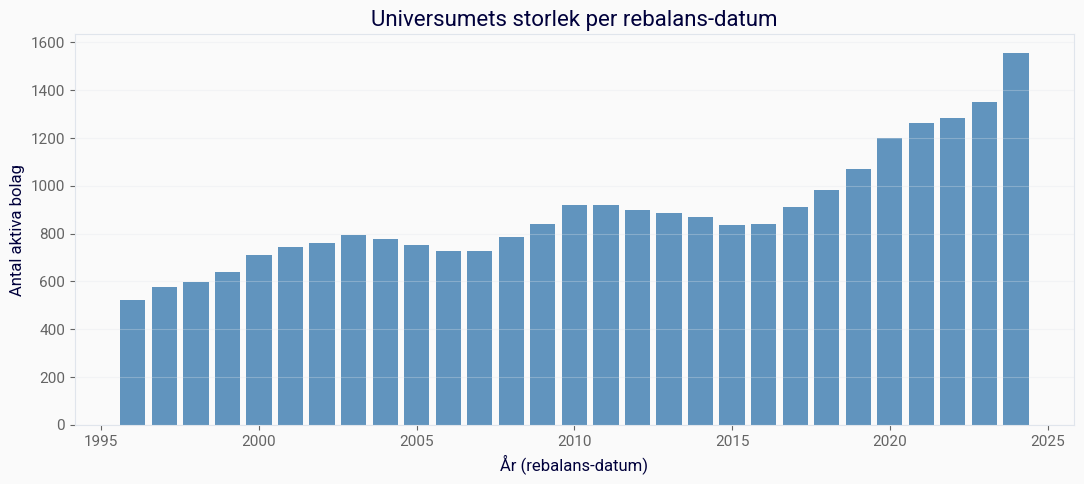

min      523.0
50%      842.0
mean     888.0
max     1556.0


In [104]:
# === Diagnostik 1: universumets storlek per rebalans-datum ===
# Precomputera aktivt universum per rebalans-datum (återanvänds i nästa cell).

PRECOMPUTED_PARTITIONS = []
universe_sizes = []
for i in range(len(MC_REBAL_DATES) - 1):
    date      = MC_REBAL_DATES[i]
    next_date = MC_REBAL_DATES[i + 1]
    top_half, bot_half = get_forward_partition(date, next_date)
    PRECOMPUTED_PARTITIONS.append((top_half, bot_half))
    universe_sizes.append({
        'date': date,
        'n_active': len(top_half) + len(bot_half),
    })

univ_df = pd.DataFrame(universe_sizes).set_index('date')

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(univ_df.index.year, univ_df['n_active'], color='steelblue', alpha=0.85)
ax.set_xlabel('År (rebalans-datum)')
ax.set_ylabel('Antal aktiva bolag')
ax.set_title('Universumets storlek per rebalans-datum')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(univ_df['n_active'].describe()[['min', '50%', 'mean', 'max']].round(0).to_string())

pf_size=  2: median=   4  range=2-8  (n=100)
pf_size=  3: median=   6  range=3-13  (n=100)
pf_size=  5: median=  33  range=31-37  (n=100)
pf_size= 10: median=  92  range=88-95  (n=100)
pf_size= 20: median= 180  range=173-186  (n=100)
pf_size= 50: median= 419  range=406-435  (n=100)
pf_size=100: median= 751  range=726-780  (n=100)
pf_size=200: median=1240  range=1206-1273  (n=100)


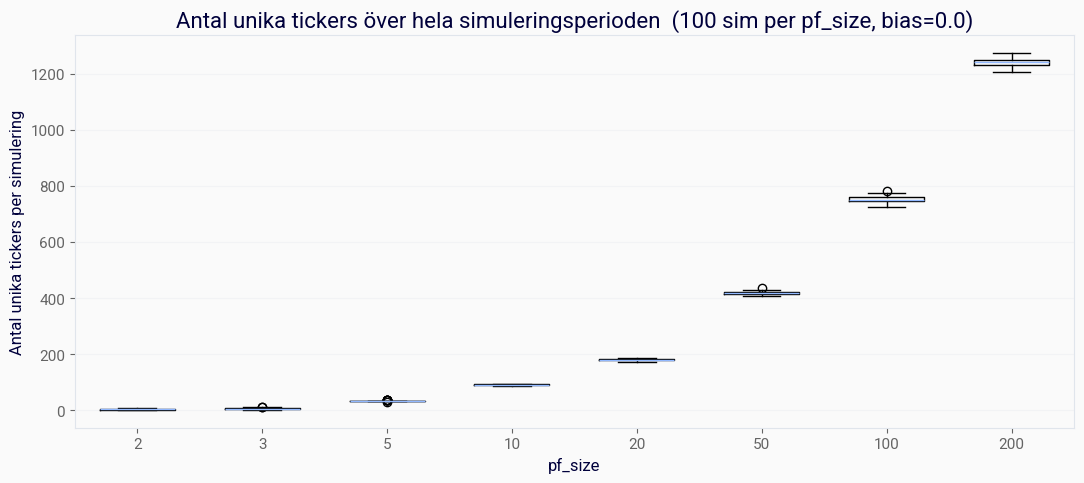

In [105]:
# === Diagnostik 2: antal unika tickers per simulering ===
# Återanvänder PRECOMPUTED_PARTITIONS från föregående cell.

def _count_unique_tickers(pf_size, seed, partitions, rebal_dates,
                          bias=0.0, max_turnover=0.3):
    rng = np.random.default_rng(seed)
    top_half, bot_half = partitions[0]
    holdings = draw_initial_holdings(top_half, bot_half, pf_size, bias, rng)
    seen = set(holdings)
    for i in range(1, len(partitions)):
        top_half, bot_half = partitions[i]
        holdings = rebalance_holdings(
            rebal_dates[i], holdings, top_half, bot_half, pf_size, bias, rng,
            max_turnover,
        )
        seen.update(holdings)
    return len(seen)


DIAG_NUM_RUNS = 100
DIAG_BIAS     = 0.0

unique_counts = {}
for sz in MC_PF_SIZES:
    counts = []
    for seed in range(DIAG_NUM_RUNS):
        try:
            counts.append(_count_unique_tickers(
                sz, seed, PRECOMPUTED_PARTITIONS, MC_REBAL_DATES,
                bias=DIAG_BIAS, max_turnover=MC_MAX_TURNOVER,
            ))
        except Exception:
            pass
    unique_counts[sz] = counts
    print(f'pf_size={sz:>3}: median={int(np.median(counts)):>4}  '
          f'range={min(counts)}-{max(counts)}  (n={len(counts)})')


fig, ax = plt.subplots(figsize=(11, 5))
positions = list(range(len(MC_PF_SIZES)))
ax.boxplot([unique_counts[sz] for sz in MC_PF_SIZES],
           positions=positions, widths=0.6)
ax.set_xticks(positions)
ax.set_xticklabels(MC_PF_SIZES)
ax.set_xlabel('pf_size')
ax.set_ylabel('Antal unika tickers per simulering')
ax.set_title(
    f'Antal unika tickers över hela simuleringsperioden  '
    f'({DIAG_NUM_RUNS} sim per pf_size, bias={DIAG_BIAS})'
)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
MC_RESULT_FILE = 'result_mc_v4e.pkl'
MC_SAVE_PATH   = os.path.join(RESULTATFOLDER, MC_RESULT_FILE)

answer = input(f'⚠️  Kör ny MC-simulering och spara {MC_RESULT_FILE}? (ja/nej): ')

if answer.strip().lower() != 'ja':
    print('❌ Ingen simulering körd.')
else:
    os.makedirs(RESULTATFOLDER, exist_ok=True)
    mc_raw = {}
    combos = list(product(MC_BIASES, MC_WEIGHTINGS, MC_PF_SIZES))

    for i, (bias, wgt, sz) in enumerate(combos):
        print(f'  [{i+1}/{len(combos)}] bias={bias:<4} wgt={wgt:<12} sz={sz:>3}', end='\r')
        mc_raw[(bias, wgt, sz)] = run_mc_simulation(
            bias, wgt, sz,
            num_runs=MC_NUM_RUNS,
            rebal_dates=MC_REBAL_DATES,
            max_turnover=MC_MAX_TURNOVER,
        )

    frames = []
    for (bias, wgt, sz), df in mc_raw.items():
        df = df.copy()
        df.index = pd.MultiIndex.from_arrays(
            [[bias]*len(df), [wgt]*len(df), [sz]*len(df), df.index],
            names=['bias', 'weighting', 'pf_size', 'metric']
        )
        frames.append(df)
    mc_result = pd.concat(frames)
    mc_result.to_pickle(MC_SAVE_PATH)
    print(f'\n✅ Sparat till: {MC_SAVE_PATH}')

In [76]:
MC_SAVE_PATH


'analysresultat\\result_mc_v4d3.pkl'

## 4. Ladda resultat

In [ ]:
#pd.concat([pd.read_pickle('analysresultat\\result_mc_v4d3.pkl').rename(lambda x:x+5000, axis=1), pd.read_pickle('analysresultat\\result_mc_v4d_combined.pkl')], axis=1).sort_index(axis=1).to_pickle('analysresultat\\result_mc_v4d_combined.pkl')  

In [78]:
MC_SAVE_PATH='analysresultat\\result_mc_v4d_combined.pkl'


In [79]:
mc_result = pd.read_pickle(MC_SAVE_PATH)
broken_metrics = ['Beta', 'Downside Capture', 'Upside capture', 'Batting average']
mc_result = mc_result[~mc_result.index.get_level_values('metric').isin(broken_metrics)]

index_rets = (
    MARKET_RETURNS['market_return']
    .add(1).cumprod().resample('ME').last()
    .pct_change(fill_method=None).replace(0, np.nan).dropna()
    .rename(None)
)
bench_kfs = get_kfs(
    index_rets.loc[MC_START:MC_END].to_frame(),
    index_rets.loc[MC_START:MC_END].to_frame()
).loc[0]

MC_BIASES        = list(mc_result.index.levels[0])
MC_WEIGHTINGS    = list(mc_result.index.levels[1])
MC_PF_SIZES      = list(mc_result.index.levels[2])

print('Resultat laddade:', mc_result.shape)
print('Nivåer:', mc_result.index.names)
print('Benchmark Return:', round(bench_kfs['Return'], 4))

Resultat laddade: (384, 10000)
Nivåer: ['bias', 'weighting', 'pf_size', 'metric']
Benchmark Return: 0.1167


## 5. Analys

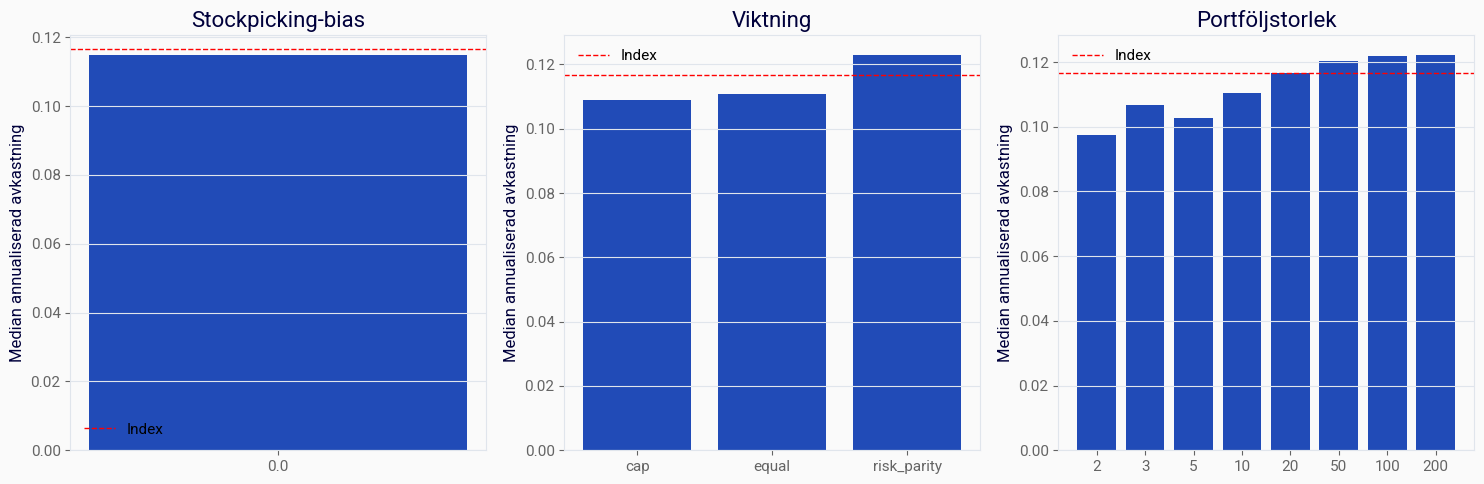

In [80]:
# === Median-avkastning per dimension ===
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metric = 'Return'

dims = [
    ('bias',      'Stockpicking-bias',  MC_BIASES),
    ('weighting', 'Viktning',           MC_WEIGHTINGS),
    ('pf_size',   'Portföljstorlek',    MC_PF_SIZES),
]

for ax, (level, label, order) in zip(axes, dims):
    data = mc_result.xs(metric, level='metric')
    medians = data.groupby(level=level).median().median(axis=1)
    medians = medians.reindex(order)
    if medians.isna().all():
        medians = data.groupby(level=level).median().median(axis=1)
    ax.bar(medians.index.astype(str), medians.values)
    ax.axhline(bench_kfs[metric], color='red', linestyle='--', label='Index')
    ax.set_title(label)
    ax.set_ylabel('Median annualiserad avkastning')
    ax.legend()

plt.tight_layout()
plt.show()

sz_focus = 20  (tillgängliga pf_sizes: [2, 3, 5, 10, 20, 50, 100, 200])


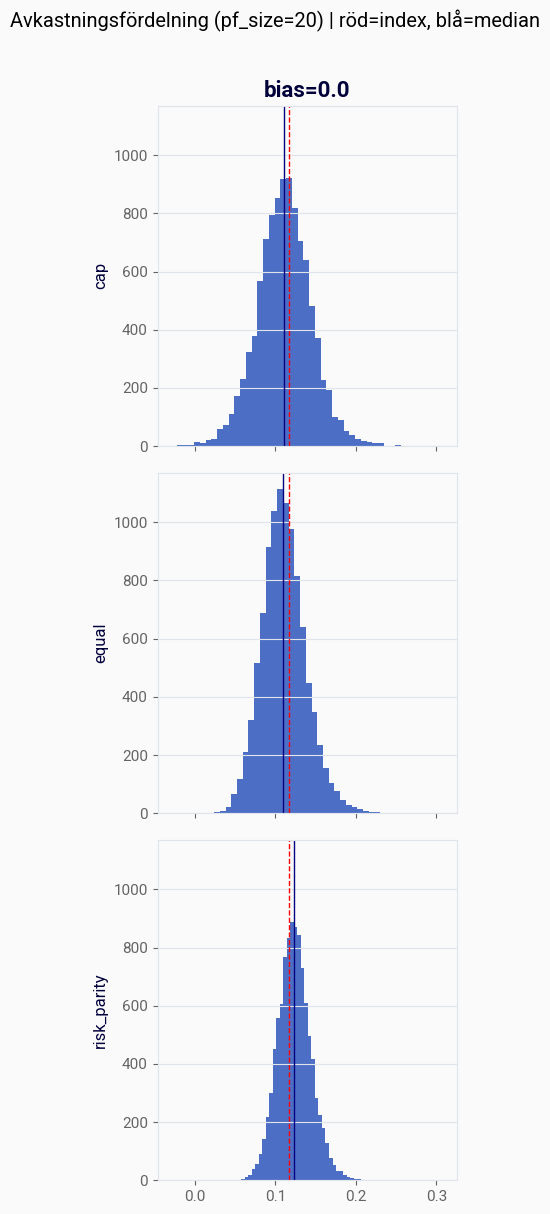

In [81]:
# === Fördelning av avkastning per bias × viktning ===
metric = 'Return'

sz_focus = MC_PF_SIZES[len(MC_PF_SIZES) // 2]
print(f'sz_focus = {sz_focus}  (tillgängliga pf_sizes: {MC_PF_SIZES})')

fig, axes = plt.subplots(
    len(MC_WEIGHTINGS), len(MC_BIASES),
    figsize=(4 * len(MC_BIASES), 4 * len(MC_WEIGHTINGS)),
    sharex=True, sharey=True
)
axes = np.array(axes).reshape(len(MC_WEIGHTINGS), len(MC_BIASES))

bench_val = bench_kfs[metric]

for row, wgt in enumerate(MC_WEIGHTINGS):
    for col, bias in enumerate(MC_BIASES):
        ax = axes[row][col]
        try:
            result = mc_result.xs(
                (bias, wgt, sz_focus, metric),
                level=['bias', 'weighting', 'pf_size', 'metric']
            )
            if result.empty:
                raise KeyError('tom')
            vals = result.iloc[0].dropna()
        except (KeyError, IndexError):
            ax.set_title(f'bias={bias}\n(ej tillgänglig)', color='grey')
            continue
        ax.hist(vals, bins=40, edgecolor='none', alpha=0.8)
        ax.axvline(bench_val, color='red', linestyle='--', linewidth=1, label='Index')
        ax.axvline(float(vals.median()), color='navy', linestyle='-', linewidth=1, label='Median')
        if row == 0:
            ax.set_title(f'bias={bias}', fontweight='bold')
        if col == 0:
            ax.set_ylabel(wgt)

fig.suptitle(f'Avkastningsfördelning (pf_size={sz_focus}) | röd=index, blå=median', y=1.01)
plt.tight_layout()
plt.show()

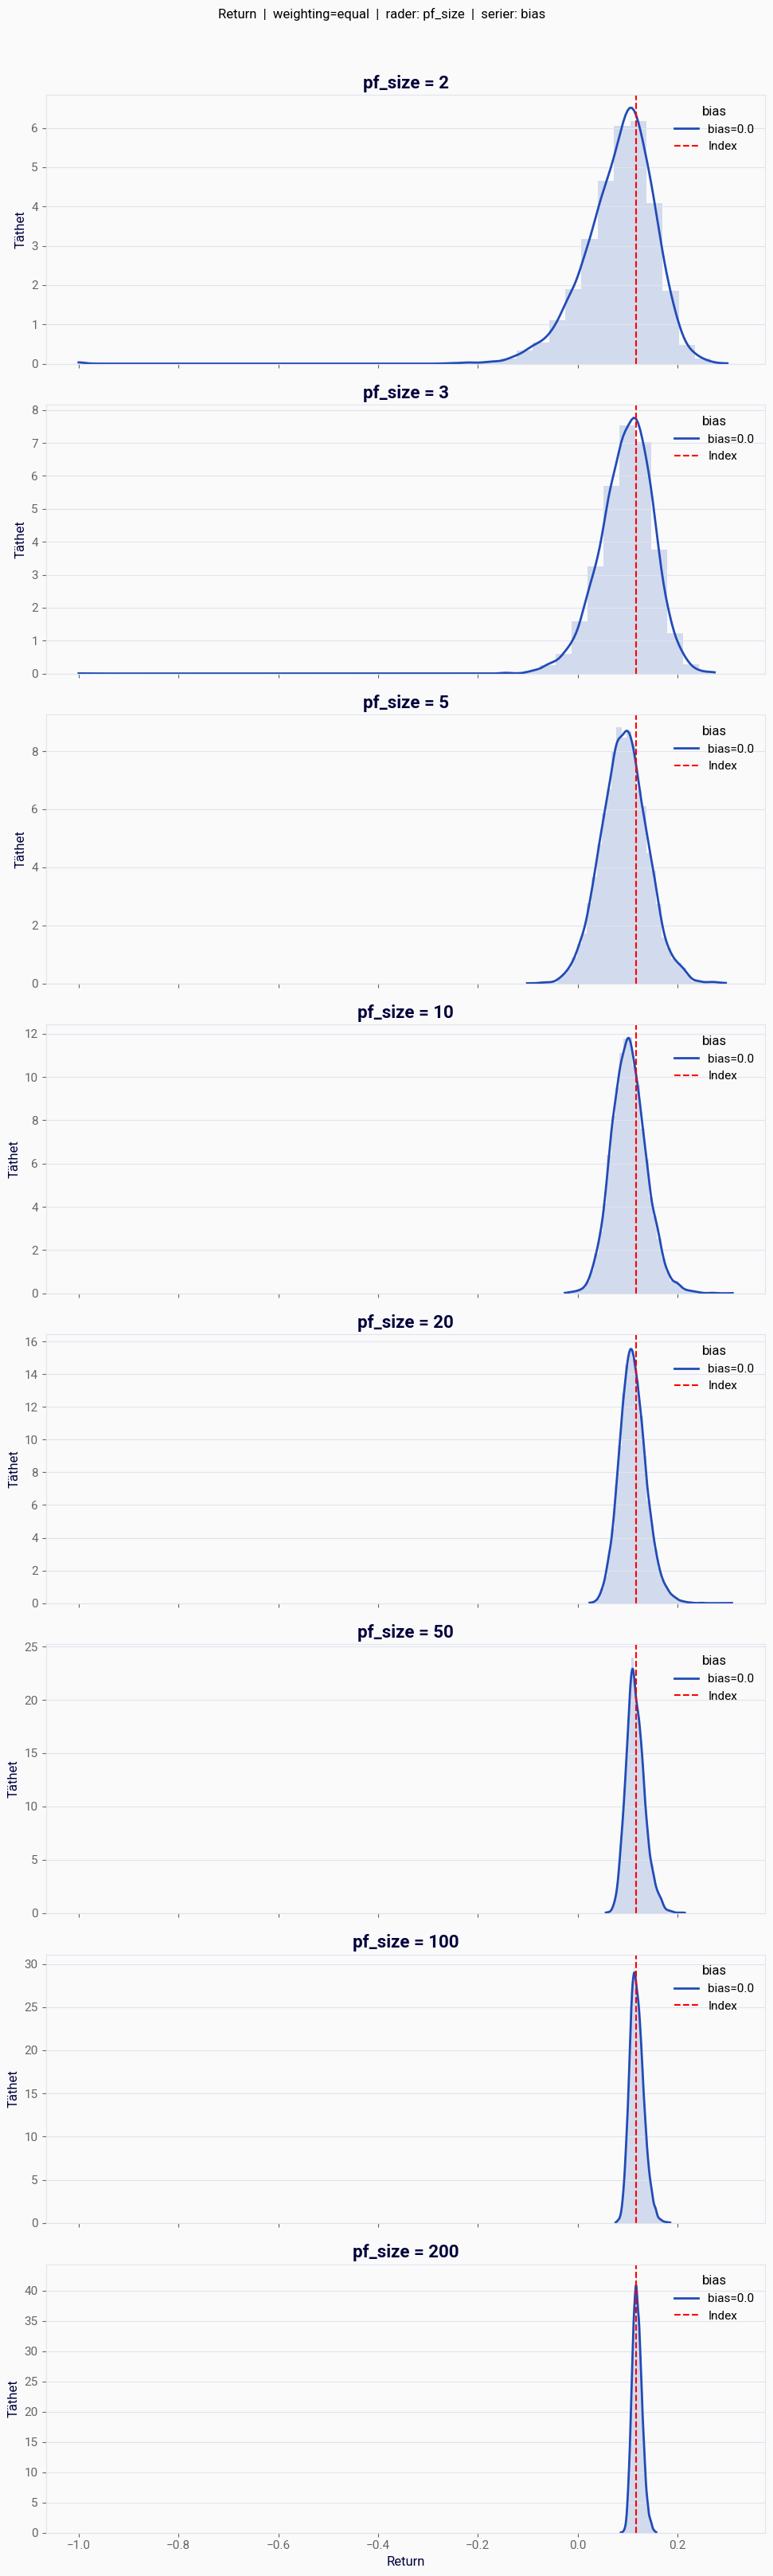

In [82]:
from scipy.stats import gaussian_kde

# ── Inställningar ────────────────────────────────────────────────────────
kf        = 'Return'
fixed_dim = ('weighting', 'equal')    # (dimension, värde) som hålls fast
row_dim   = 'pf_size'                 # en rad per portföljstorlek
chart_dim = 'bias'                    # en serie per bias-nivå

_dim_values = {
    'bias':      MC_BIASES,
    'weighting': MC_WEIGHTINGS,
    'pf_size':   MC_PF_SIZES,
}
row_values   = _dim_values[row_dim]
chart_values = _dim_values[chart_dim]
fixed_level, fixed_val = fixed_dim

_level_order = list(mc_result.index.names)

def _get_vals(row_val, chart_val):
    selector = {
        row_dim:     row_val,
        chart_dim:   chart_val,
        fixed_level: fixed_val,
        'metric':    kf,
    }
    key = tuple(selector[lvl] for lvl in _level_order)
    try:
        vals = mc_result.loc[key]
        if isinstance(vals, pd.DataFrame):
            vals = vals.squeeze()
        return vals.dropna().astype(float)
    except KeyError:
        return pd.Series(dtype=float)

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig, axes = plt.subplots(
    len(row_values), 1,
    figsize=(10, 4 * len(row_values)),
    sharex=True
)
if len(row_values) == 1:
    axes = [axes]

for ax, row_val in zip(axes, row_values):
    for ci, chart_val in enumerate(chart_values):
        vals = _get_vals(row_val, chart_val)
        if len(vals) < 2:
            continue
        color = colors[ci % len(colors)]
        label = f'bias={chart_val}'
        ax.hist(vals, bins=40, alpha=0.18, color=color, density=True)
        kde = gaussian_kde(vals)
        x   = np.linspace(vals.min(), vals.max(), 300)
        ax.plot(x, kde(x), color=color, linewidth=2, label=label)

    ax.axvline(bench_kfs[kf], color='red', linestyle='--', linewidth=1.5, label='Index')
    ax.set_title(f'{row_dim} = {row_val}', fontweight='bold')
    ax.set_ylabel('Täthet')
    ax.legend(title=chart_dim, framealpha=0.7)

axes[-1].set_xlabel(kf)
fig.suptitle(
    f'{kf}  |  {fixed_level}={fixed_val}  |  rader: {row_dim}  |  serier: {chart_dim}',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()

## 6. Hur mycket bias krävs för att en koncentrerad portfölj ska matcha en diversifierad?

Vi söker den bias-nivå där en mindre portfölj når samma **certainty equivalent** som den största portföljen vid bias=0 (oselekterad benchmark).

$$CE = \mu - \frac{\lambda}{2} \cdot \sigma^2$$

där μ och σ² är medianen respektive variansen av annualiserad avkastning och volatilitet över MC-körningarna. Riskaversionsparametern λ styr avvägningen mellan avkastning och risk.

Jämför: 2-aktier vs referens 200-aktier (bias=0)


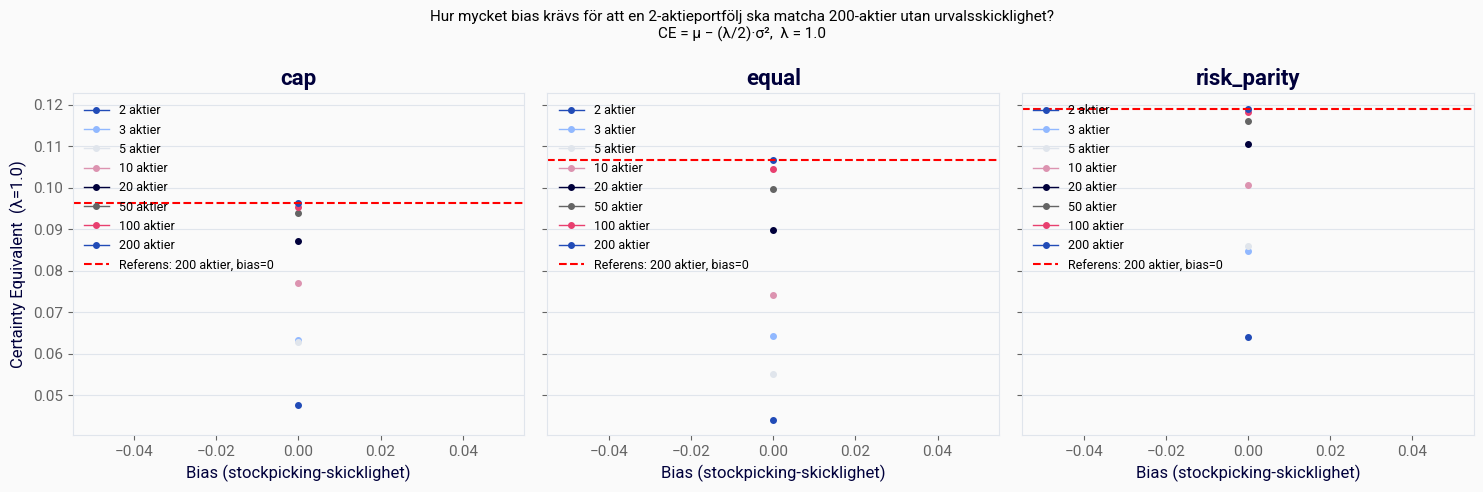


Bias-nivå där 2-aktieportfölj ≈ 200-aktieportfölj (bias=0), λ=1.0:
                      cap equal risk_parity
Crossover bias (pf=2)   —     —           —


In [83]:
RISK_AVERSION = 1.0  # λ — ändra här för känslighetsanalys

PF_SMALL = MC_PF_SIZES[0]
PF_REF   = MC_PF_SIZES[-1]
print(f'Jämför: {PF_SMALL}-aktier vs referens {PF_REF}-aktier (bias=0)')


def median_ce(bias, pf_size, weighting, lam=RISK_AVERSION):
    '''Median CE = E[r] − (λ/2)·Var[r] över MC-körningarna.'''
    try:
        ret = mc_result.xs(
            (bias, weighting, pf_size, 'Return'),
            level=['bias', 'weighting', 'pf_size', 'metric']
        )
        vol = mc_result.xs(
            (bias, weighting, pf_size, 'Vol'),
            level=['bias', 'weighting', 'pf_size', 'metric']
        )
        if ret.empty or vol.empty:
            return np.nan
        r = ret.iloc[0].dropna().astype(float)
        v = vol.iloc[0].dropna().astype(float)
        return (r - (lam / 2) * v**2).median()
    except (KeyError, IndexError):
        return np.nan


def find_crossover(ces_small, reference, biases):
    '''Linjär interpolation: bias där ces_small korsas med reference.'''
    for i in range(len(biases) - 1):
        y0, y1 = ces_small[i], ces_small[i + 1]
        if np.isnan(y0) or np.isnan(y1):
            continue
        if (y0 - reference) * (y1 - reference) <= 0:
            t = (reference - y0) / (y1 - y0) if y1 != y0 else 0.0
            return biases[i] + t * (biases[i + 1] - biases[i])
    return np.nan


_palette = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors_sz = {sz: _palette[i % len(_palette)] for i, sz in enumerate(MC_PF_SIZES)}

fig, axes = plt.subplots(1, len(MC_WEIGHTINGS), figsize=(15, 5), sharey=True)
crossover_table = {}

for ax, wgt in zip(axes, MC_WEIGHTINGS):
    ref = median_ce(0.0, PF_REF, wgt)

    for sz in MC_PF_SIZES:
        ces = [median_ce(b, sz, wgt) for b in MC_BIASES]
        ax.plot(MC_BIASES, ces, marker='o', markersize=4,
                color=colors_sz[sz], label=f'{sz} aktier')

    ax.axhline(ref, color='red', linestyle='--', linewidth=1.5,
               label=f'Referens: {PF_REF} aktier, bias=0')

    ces_small = [median_ce(b, PF_SMALL, wgt) for b in MC_BIASES]
    xover = find_crossover(ces_small, ref, MC_BIASES)
    crossover_table[wgt] = round(xover, 3) if not np.isnan(xover) else '—'

    if not np.isnan(xover):
        ax.axvline(xover, color='grey', linestyle=':', linewidth=1.5)
        ax.annotate(
            f'bias ≈ {xover:.2f}',
            xy=(xover, ref),
            xytext=(min(xover + 0.02, max(MC_BIASES) - 0.02), ref),
            fontsize=9, color='dimgrey',
            arrowprops=dict(arrowstyle='->', color='dimgrey', lw=0.8),
        )

    ax.set_title(wgt, fontweight='bold')
    ax.set_xlabel('Bias (stockpicking-skicklighet)')
    ax.legend(fontsize=9, loc='upper left')

axes[0].set_ylabel(f'Certainty Equivalent  (λ={RISK_AVERSION})')
fig.suptitle(
    f'Hur mycket bias krävs för att en {PF_SMALL}-aktieportfölj ska matcha {PF_REF}-aktier utan urvalsskicklighet?\n'
    f'CE = μ − (λ/2)·σ²,  λ = {RISK_AVERSION}',
    fontsize=11,
)
plt.tight_layout()
plt.show()

print(f'\nBias-nivå där {PF_SMALL}-aktieportfölj ≈ {PF_REF}-aktieportfölj (bias=0), λ={RISK_AVERSION}:')
print(pd.DataFrame({f'Crossover bias (pf={PF_SMALL})': crossover_table}).T.to_string())

## 7. Risk–avkastningsprofil per viktning

Scatter-plot med **volatilitet** (x) och **avkastning** (y) baserade på median över MC-körningarna. Färgen visar bias-nivån (colorbar) och markörformen visar portföljstorleken.

C:\Users\JonasAnderssonTuomaa\AppData\Local\Temp\ipykernel_8260\1787961794.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


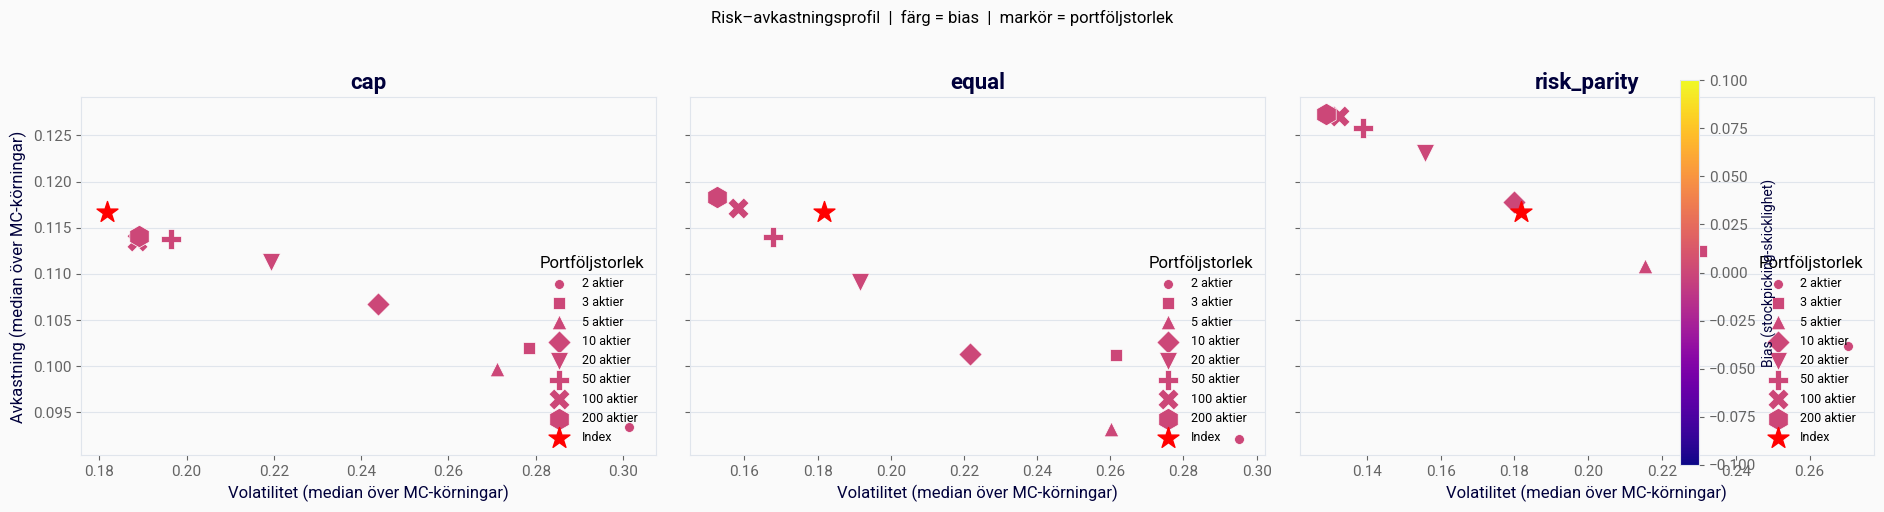

In [84]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

cmap = cm.plasma
bias_arr = np.array(MC_BIASES, dtype=float)
norm = mcolors.Normalize(vmin=bias_arr.min(), vmax=bias_arr.max())

_marker_shapes = ['o', 's', '^', 'D', 'v', 'P', 'X', 'h']
_marker_sizes  = [50, 80, 110, 140, 170, 200, 230, 260]
markers  = {sz: _marker_shapes[i % len(_marker_shapes)] for i, sz in enumerate(MC_PF_SIZES)}
msizes   = {sz: _marker_sizes[i % len(_marker_sizes)]   for i, sz in enumerate(MC_PF_SIZES)}

fig, axes = plt.subplots(1, len(MC_WEIGHTINGS), figsize=(6 * len(MC_WEIGHTINGS) + 1, 5),
                         sharey=True)

for ax, wgt in zip(axes, MC_WEIGHTINGS):
    for sz in MC_PF_SIZES:
        med_vols, med_rets, bias_vals = [], [], []

        for bias in MC_BIASES:
            try:
                ret_row = mc_result.xs(
                    (bias, wgt, sz, 'Return'),
                    level=['bias', 'weighting', 'pf_size', 'metric']
                )
                vol_row = mc_result.xs(
                    (bias, wgt, sz, 'Vol'),
                    level=['bias', 'weighting', 'pf_size', 'metric']
                )
                if ret_row.empty or vol_row.empty:
                    continue
                med_rets.append(ret_row.iloc[0].dropna().astype(float).median())
                med_vols.append(vol_row.iloc[0].dropna().astype(float).median())
                bias_vals.append(float(bias))
            except (KeyError, IndexError):
                continue

        if not med_vols:
            continue

        ax.scatter(
            med_vols, med_rets,
            c=bias_vals, cmap=cmap, norm=norm,
            marker=markers[sz], s=msizes[sz],
            label=f'{sz} aktier',
            edgecolors='white', linewidths=0.5, zorder=3,
        )

    ax.scatter(
        [bench_kfs['Vol']], [bench_kfs['Return']],
        marker='*', s=250, color='red', zorder=5, label='Index'
    )

    ax.set_title(wgt, fontweight='bold')
    ax.set_xlabel('Volatilitet (median över MC-körningar)')
    ax.legend(fontsize=9, loc='lower right', title='Portföljstorlek')

axes[0].set_ylabel('Avkastning (median över MC-körningar)')

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.tolist(), orientation='vertical',
                    fraction=0.015, pad=0.02)
cbar.set_label('Bias (stockpicking-skicklighet)', fontsize=10)

fig.suptitle(
    'Risk–avkastningsprofil  |  färg = bias  |  markör = portföljstorlek',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()

## 8. Erforderlig bias per portföljstorlek och riskaversion

Tabeller (en per viktning) som visar hur mycket bias som krävs för att en portfölj av given storlek ska nå samma certainty equivalent som en `PF_REF`-aktieportfölj utan urvalsskicklighet (bias=0).

In [85]:
LAMBDA_VALS = [0.5, 1.0, 2.0]


def crossover_bias(pf_size, weighting, lam):
    '''Minsta bias där pf_size-portföljen når samma CE som PF_REF vid bias=0.'''
    ref = median_ce(0.0, PF_REF, weighting, lam=lam)
    if np.isnan(ref):
        return np.nan
    ces = [median_ce(b, pf_size, weighting, lam=lam) for b in MC_BIASES]
    return find_crossover(ces, ref, MC_BIASES)


for wgt in MC_WEIGHTINGS:
    rows = {}
    for sz in MC_PF_SIZES:
        if sz == PF_REF:
            rows[sz] = {lam: 0.0 for lam in LAMBDA_VALS}
            continue
        rows[sz] = {}
        for lam in LAMBDA_VALS:
            xover = crossover_bias(sz, wgt, lam)
            rows[sz][lam] = xover

    tbl = pd.DataFrame(rows, index=LAMBDA_VALS).T
    tbl.index.name   = 'Portföljstorlek'
    tbl.columns.name = 'Riskaversion (λ)'
    tbl.columns      = [f'λ = {l}' for l in LAMBDA_VALS]

    def _fmt(v):
        if np.isnan(v):
            return '> max'
        if v == 0.0:
            return '— (referens)'
        return f'{v:.3f}'

    print(f'\n{"─"*50}')
    print(f'Viktning: {wgt}')
    print(f'Bias-nivå för att matcha {PF_REF}-aktieportfölj (bias=0)')
    print(f'{"─"*50}')
    print(tbl.map(_fmt).to_string())
print()


──────────────────────────────────────────────────
Viktning: cap
Bias-nivå för att matcha 200-aktieportfölj (bias=0)
──────────────────────────────────────────────────
                      λ = 0.5       λ = 1.0       λ = 2.0
Portföljstorlek                                          
2                       > max         > max         > max
3                       > max         > max         > max
5                       > max         > max         > max
10                      > max         > max         > max
20                      > max         > max         > max
50                      > max         > max         > max
100                     > max         > max         > max
200              — (referens)  — (referens)  — (referens)

──────────────────────────────────────────────────
Viktning: equal
Bias-nivå för att matcha 200-aktieportfölj (bias=0)
──────────────────────────────────────────────────
                      λ = 0.5       λ = 1.0       λ = 2.0
Portföljstorlek       

## 9. Erforderlig bias för att matcha benchmark (cap-viktad)

Samma upplägg som sektion 8, men referensnivån är **benchmarkindexets** certainty equivalent snarare än den diversifierade portföljens.

In [86]:
WGT_FOCUS = 'cap'

rows = {}
for sz in MC_PF_SIZES:
    rows[sz] = {}
    for lam in LAMBDA_VALS:
        bench_ce = bench_kfs['Return'] - (lam / 2) * bench_kfs['Vol'] ** 2
        ces = [median_ce(b, sz, WGT_FOCUS, lam=lam) for b in MC_BIASES]
        rows[sz][lam] = find_crossover(ces, bench_ce, MC_BIASES)

tbl = pd.DataFrame(rows, index=LAMBDA_VALS).T
tbl.index.name = 'Portföljstorlek'
tbl.columns    = [f'λ = {l}' for l in LAMBDA_VALS]


def _fmt(v):
    if np.isnan(v):
        return '> max'
    return f'{v:.3f}'


print(f'Viktning: {WGT_FOCUS}')
print('Bias-nivå för att matcha benchmark CE')
print()
print(tbl.map(_fmt).to_string())

Viktning: cap
Bias-nivå för att matcha benchmark CE

                λ = 0.5 λ = 1.0 λ = 2.0
Portföljstorlek                        
2                 > max   > max   > max
3                 > max   > max   > max
5                 > max   > max   > max
10                > max   > max   > max
20                > max   > max   > max
50                > max   > max   > max
100               > max   > max   > max
200               > max   > max   > max


## 10. Analys relativt benchmarkavkastning

Samma plottar som i avsnitt 5 men med portföljavkastningar uttryckta som **överavkastning vs marknadsindex** (`Return − bench_kfs['Return']`). Nollinjen representerar benchmark — värden ovanför betyder överprestation, värden under underperformance.

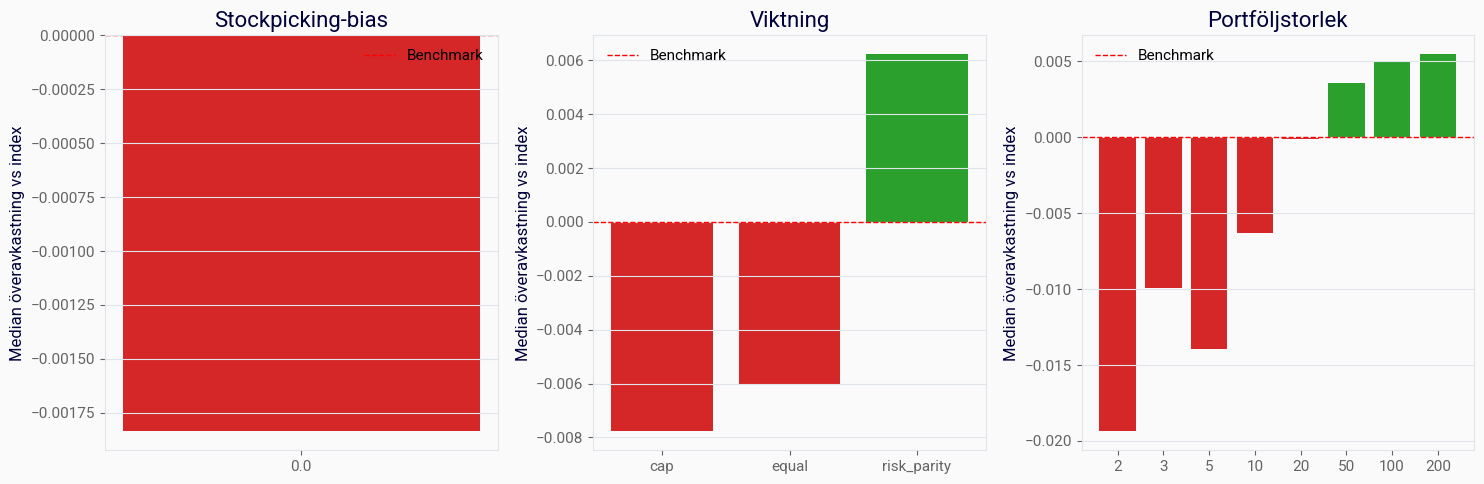

In [87]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metric = 'Return'

dims = [
    ('bias',      'Stockpicking-bias',  MC_BIASES),
    ('weighting', 'Viktning',           MC_WEIGHTINGS),
    ('pf_size',   'Portföljstorlek',    MC_PF_SIZES),
]

for ax, (level, label, order) in zip(axes, dims):
    data = mc_result.xs(metric, level='metric')
    medians = data.groupby(level=level).median().median(axis=1)
    medians = medians.reindex(order)
    if medians.isna().all():
        medians = data.groupby(level=level).median().median(axis=1)
    excess = medians - bench_kfs[metric]
    bar_colors = ['tab:green' if v >= 0 else 'tab:red' for v in excess.values]
    ax.bar(excess.index.astype(str), excess.values, color=bar_colors)
    ax.axhline(0, color='red', linestyle='--', linewidth=1, label='Benchmark')
    ax.set_title(label)
    ax.set_ylabel('Median överavkastning vs index')
    ax.legend()

plt.tight_layout()
plt.show()

sz_focus = 20  (tillgängliga pf_sizes: [2, 3, 5, 10, 20, 50, 100, 200])


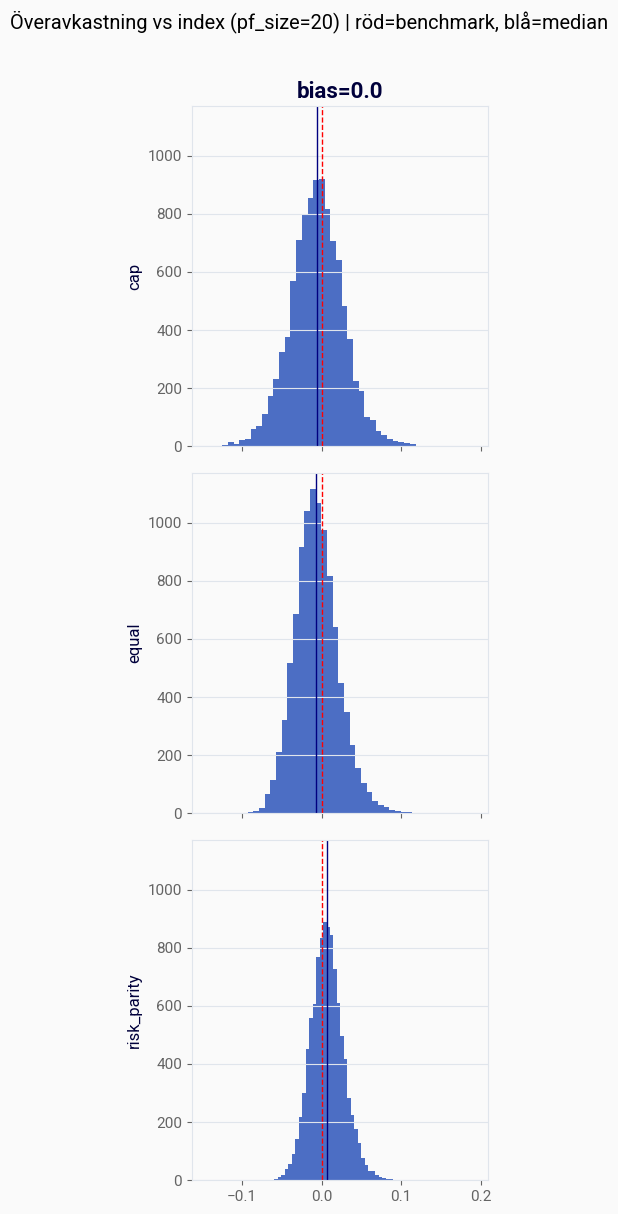

In [88]:
metric = 'Return'
sz_focus = MC_PF_SIZES[len(MC_PF_SIZES) // 2]
print(f'sz_focus = {sz_focus}  (tillgängliga pf_sizes: {MC_PF_SIZES})')

fig, axes = plt.subplots(
    len(MC_WEIGHTINGS), len(MC_BIASES),
    figsize=(4 * len(MC_BIASES), 4 * len(MC_WEIGHTINGS)),
    sharex=True, sharey=True
)
axes = np.array(axes).reshape(len(MC_WEIGHTINGS), len(MC_BIASES))

bench_val = bench_kfs[metric]

for row, wgt in enumerate(MC_WEIGHTINGS):
    for col, bias in enumerate(MC_BIASES):
        ax = axes[row][col]
        try:
            result = mc_result.xs(
                (bias, wgt, sz_focus, metric),
                level=['bias', 'weighting', 'pf_size', 'metric']
            )
            if result.empty:
                raise KeyError('tom')
            vals = result.iloc[0].dropna() - bench_val
        except (KeyError, IndexError):
            ax.set_title(f'bias={bias}\n(ej tillgänglig)', color='grey')
            continue
        ax.hist(vals, bins=40, edgecolor='none', alpha=0.8)
        ax.axvline(0, color='red', linestyle='--', linewidth=1, label='Benchmark')
        ax.axvline(float(vals.median()), color='navy', linestyle='-', linewidth=1, label='Median')
        if row == 0:
            ax.set_title(f'bias={bias}', fontweight='bold')
        if col == 0:
            ax.set_ylabel(wgt)

fig.suptitle(f'Överavkastning vs index (pf_size={sz_focus}) | röd=benchmark, blå=median', y=1.01)
plt.tight_layout()
plt.show()

In [91]:
MC_WEIGHTINGS

['cap', 'equal', 'risk_parity']

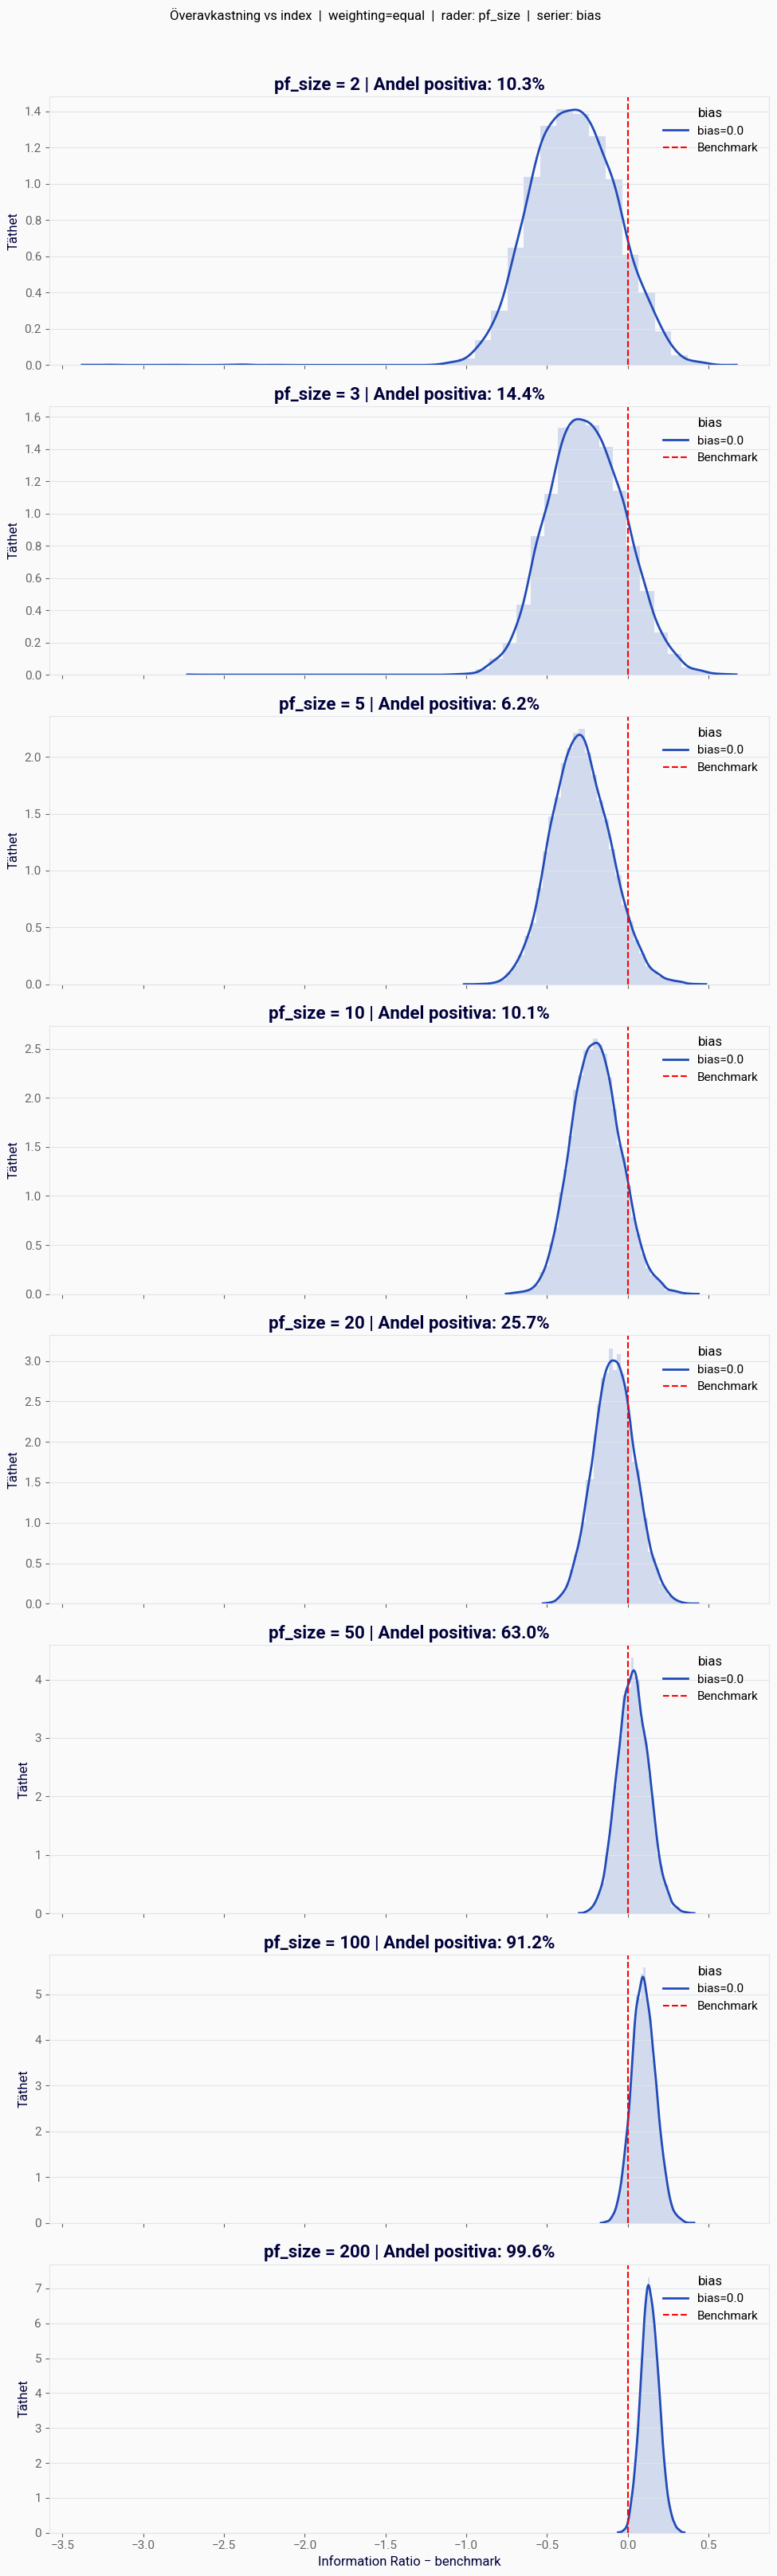

In [94]:
kf        = 'Information Ratio'
fixed_dim = ('weighting', 'equal')  # (dimension, värde) som hålls fast
row_dim   = 'pf_size'
chart_dim = 'bias'

_dim_values = {
    'bias':      MC_BIASES,
    'weighting': MC_WEIGHTINGS,
    'pf_size':   MC_PF_SIZES,
}
row_values   = _dim_values[row_dim]
chart_values = _dim_values[chart_dim]
fixed_level, fixed_val = fixed_dim

_level_order = list(mc_result.index.names)


def _get_excess(row_val, chart_val):
    selector = {
        row_dim:     row_val,
        chart_dim:   chart_val,
        fixed_level: fixed_val,
        'metric':    kf,
    }
    key = tuple(selector[lvl] for lvl in _level_order)
    try:
        vals = mc_result.loc[key]
        if isinstance(vals, pd.DataFrame):
            vals = vals.squeeze()
        return vals.dropna().astype(float) - bench_kfs[kf]
    except KeyError:
        return pd.Series(dtype=float)


colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig, axes = plt.subplots(
    len(row_values), 1,
    figsize=(10, 4 * len(row_values)),
    sharex=True
)
if len(row_values) == 1:
    axes = [axes]

for ax, row_val in zip(axes, row_values):
    for ci, chart_val in enumerate(chart_values):
        vals = _get_excess(row_val, chart_val)
        if len(vals) < 2:
            continue
        color = colors[ci % len(colors)]
        label = f'bias={chart_val}'
        ax.hist(vals, bins=40, alpha=0.18, color=color, density=True)
        kde = gaussian_kde(vals)
        x   = np.linspace(vals.min(), vals.max(), 300)
        ax.plot(x, kde(x), color=color, linewidth=2, label=label)

    ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Benchmark')
    ax.set_title(f'{row_dim} = {row_val} | Andel positiva: {(vals>0).mean():.1%}', fontweight='bold')
    ax.set_ylabel('Täthet')
    ax.legend(title=chart_dim, framealpha=0.7)

axes[-1].set_xlabel(f'{kf} − benchmark')
fig.suptitle(
    f'Överavkastning vs index  |  {fixed_level}={fixed_val}  |  rader: {row_dim}  |  serier: {chart_dim}',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()

## 11. Bias för att matcha benchmark — CE-crossover (plot)

Samma plot som i avsnitt 6 men referenslinjen är **benchmarkindexets** certainty equivalent istället för en stor diversifierad MC-portfölj utan urvalsskicklighet. Visar för varje portföljstorlek hur mycket bias som krävs för att matcha index CE-justerat.

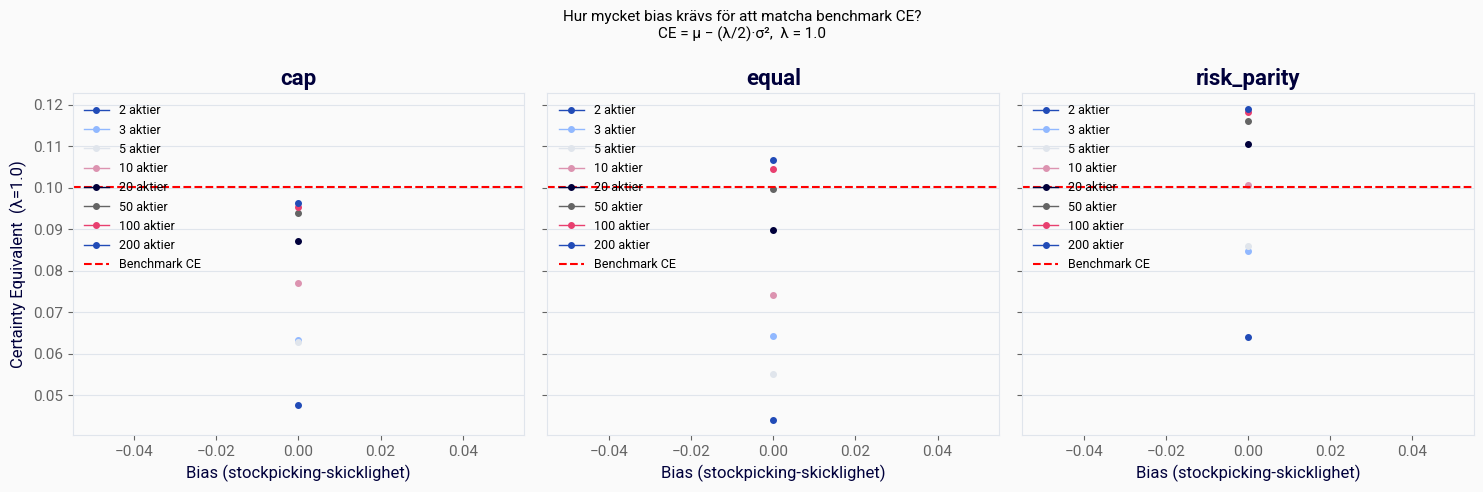


Bias-nivå där portfölj ≈ benchmark CE, λ=1.0:
     cap  equal  risk_parity
2    NaN    NaN          NaN
3    NaN    NaN          NaN
5    NaN    NaN          NaN
10   NaN    NaN          NaN
20   NaN    NaN          NaN
50   NaN    NaN          NaN
100  NaN    NaN          NaN
200  NaN    NaN          NaN


In [90]:
fig, axes = plt.subplots(1, len(MC_WEIGHTINGS), figsize=(15, 5), sharey=True)
crossover_vs_bench = {}

for ax, wgt in zip(axes, MC_WEIGHTINGS):
    bench_ce = bench_kfs['Return'] - (RISK_AVERSION / 2) * bench_kfs['Vol'] ** 2

    for sz in MC_PF_SIZES:
        ces = [median_ce(b, sz, wgt) for b in MC_BIASES]
        ax.plot(MC_BIASES, ces, marker='o', markersize=4,
                color=colors_sz[sz], label=f'{sz} aktier')

    ax.axhline(bench_ce, color='red', linestyle='--', linewidth=1.5,
               label='Benchmark CE')

    crossover_vs_bench[wgt] = {}
    for sz in MC_PF_SIZES:
        ces = [median_ce(b, sz, wgt) for b in MC_BIASES]
        xover = find_crossover(ces, bench_ce, MC_BIASES)
        crossover_vs_bench[wgt][sz] = round(xover, 3) if not np.isnan(xover) else np.nan

    ax.set_title(wgt, fontweight='bold')
    ax.set_xlabel('Bias (stockpicking-skicklighet)')
    ax.legend(fontsize=9, loc='upper left')

axes[0].set_ylabel(f'Certainty Equivalent  (λ={RISK_AVERSION})')
fig.suptitle(
    f'Hur mycket bias krävs för att matcha benchmark CE?\n'
    f'CE = μ − (λ/2)·σ²,  λ = {RISK_AVERSION}',
    fontsize=11,
)
plt.tight_layout()
plt.show()

print(f'\nBias-nivå där portfölj ≈ benchmark CE, λ={RISK_AVERSION}:')
print(pd.DataFrame(crossover_vs_bench).to_string())